In [10]:
from universeg import universeg

model = universeg(pretrained=True)
target_image_path = "/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/TotalSeg2D/s0000/colon/x_slice_img.npy"
support_image_paths = ["/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/TotalSeg2D/s0001/colon/x_slice_img.npy"]
support_label_paths = ["/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/TotalSeg2D/s0001/colon/x_slice.npy"]
import numpy as np
import torch
target_image = torch.from_numpy(np.load(target_image_path)).unsqueeze(0).unsqueeze(0).float()  # (1, 1, H, W)
support_images = torch.stack([torch.from_numpy(np.load(p)).unsqueeze(0).unsqueeze(0).float() for p in support_image_paths], dim=0)  # (1, S, 1, H, W)
support_labels = torch.stack([torch.from_numpy(np.load(p)).unsqueeze(0).unsqueeze(0).float() for p in support_label_paths], dim=0)  # (1, S, 1, H, W)

print(target_image.shape)
print(support_images.shape)
print(support_labels.shape)

# rescale to 256x256
target_image = torch.nn.functional.interpolate(target_image, size=(256, 256), mode='bilinear', align_corners=False)
support_images = torch.nn.functional.interpolate(support_images.view(-1, 1, support_images.shape[-2], support_images.shape[-1]), size=(256, 256), mode='bilinear', align_corners=False).view(support_images.shape[0], support_images.shape[1], 1, 256, 256)
support_labels = torch.nn.functional.interpolate(support_labels.view(-1, 1, support_labels.shape[-2], support_labels.shape[-1]), size=(256, 256), mode='nearest').view(support_labels.shape[0], support_labels.shape[1], 1, 256, 256)

print(target_image.shape)
print(support_images.shape)
print(support_labels.shape)

# To perform a prediction (where B=batch, S=support, H=height, W=width)
prediction = model(
    target_image,        # (B, 1, H, W)
    support_images,      # (B, S, 1, H, W)
    support_labels,      # (B, S, 1, H, W)
) # -> (B, 1, H, W)

torch.Size([1, 1, 294, 192])
torch.Size([1, 1, 1, 249, 188])
torch.Size([1, 1, 1, 249, 188])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 1, 256, 256])
torch.Size([1, 1, 1, 256, 256])


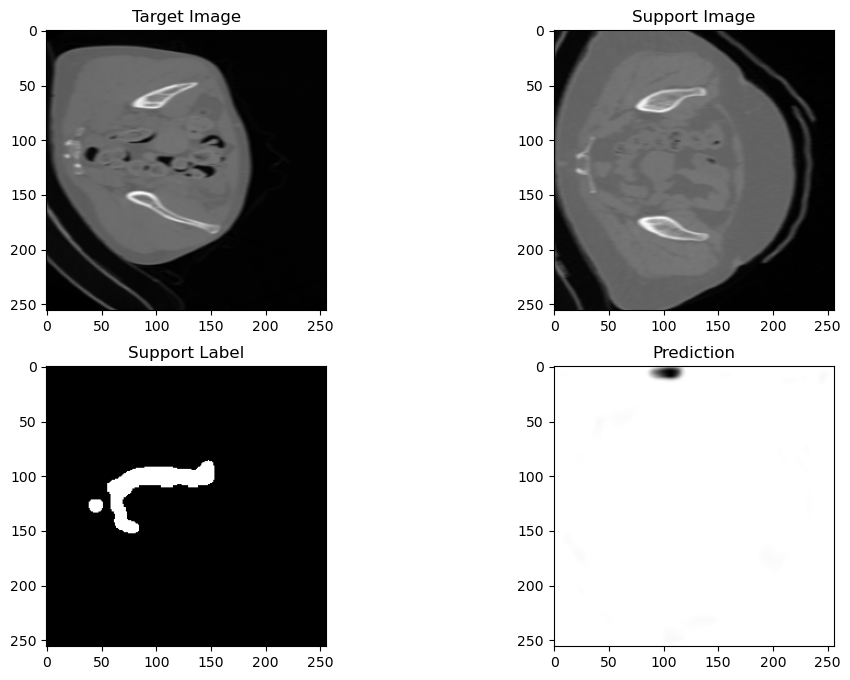

In [12]:
# plot target image, support image, support label and prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.title("Target Image")
plt.imshow(target_image[0, 0].cpu().numpy(), cmap='gray')
plt.subplot(2, 2, 2)
plt.title("Support Image")
plt.imshow(support_images[0, 0, 0].cpu().numpy(), cmap='gray')
plt.subplot(2, 2, 3)
plt.title("Support Label")
plt.imshow(support_labels[0, 0, 0].cpu().numpy(), cmap='gray')
plt.subplot(2, 2, 4)
plt.title("Prediction")
plt.imshow(prediction[0, 0].detach().cpu().numpy(), cmap='gray')
plt.show()